# Análisis Exploratorio de Datos (EDA)
**Rol:** Científico de Datos 1 (CD1)
**Objetivo:** Analizar la estructura, calidad y distribuciones de los datasets de consumo energético.

In [4]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path("../../data/raw")
smart_path = BASE_DIR / "smart_home_energy_consumption_large.csv"
uci_path = BASE_DIR / "household_power_consumption.csv"

# Carga de datasets
df_smart = pd.read_csv(smart_path)
df_uci = pd.read_csv(uci_path)

print("Datasets cargados correctamente con pathlib.")

Datasets cargados correctamente con pathlib.


### 1. Análisis del Dataset: Smart Home Energy Consumption

--- Info Smart Home ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB

--- Medidas Descriptivas ---


count    100000.000000
mean          1.499952
std           1.181176
min           0.100000
25%           0.590000
50%           1.230000
75%           1.870000
max           5.000000
Name: Energy Consumption (kWh), dtype: float64

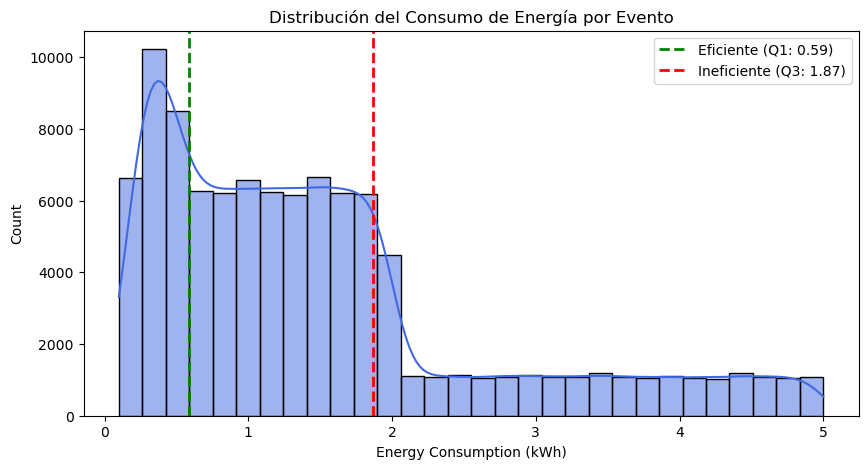

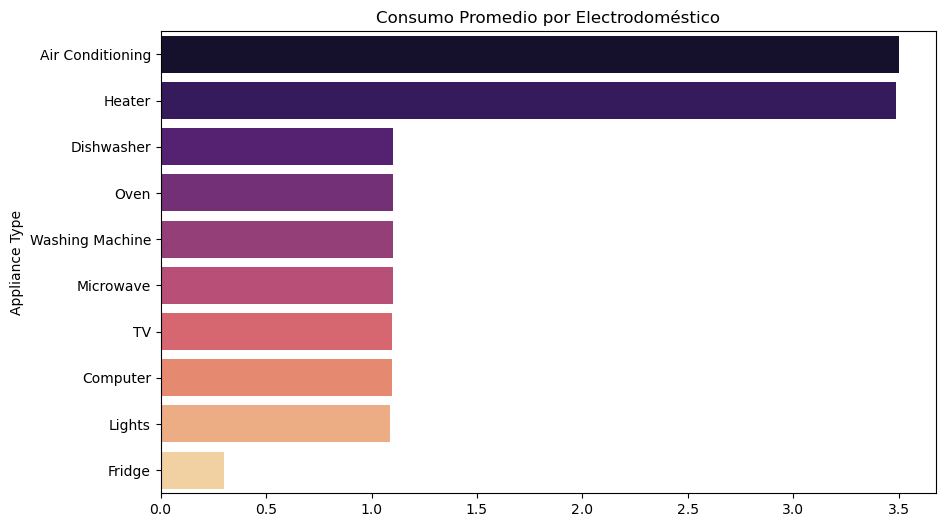

In [5]:
# Verificamos nulos y estadísticas
print("--- Info Smart Home ---")
df_smart.info()
print("\n--- Medidas Descriptivas ---")
display(df_smart['Energy Consumption (kWh)'].describe())

# Gráficos
plt.figure(figsize=(10, 5))
sns.histplot(data=df_smart, x='Energy Consumption (kWh)', bins=30, kde=True, color='royalblue')
plt.axvline(0.59, color='green', linestyle='--', linewidth=2, label='Eficiente (Q1: 0.59)')
plt.axvline(1.87, color='red', linestyle='--', linewidth=2, label='Ineficiente (Q3: 1.87)')
plt.title('Distribución del Consumo de Energía por Evento')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
consumo_promedio = df_smart.groupby('Appliance Type')['Energy Consumption (kWh)'].mean().sort_values(ascending=False)
sns.barplot(x=consumo_promedio.values, y=consumo_promedio.index, hue=consumo_promedio.index, palette='magma', legend=False)
plt.title('Consumo Promedio por Electrodoméstico')
plt.show()

--- Análisis de registros duplicados ---
Registros duplicados encontrados: 0
No se requiere eliminación.




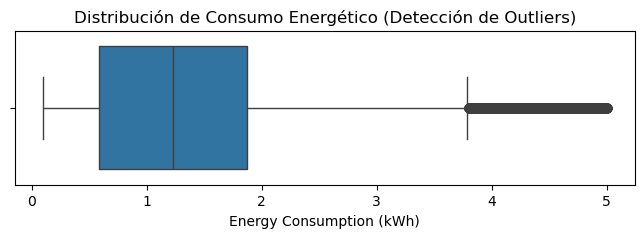

Límite superior IQR: 3.79 kWh
Cantidad de outliers detectados: 7997


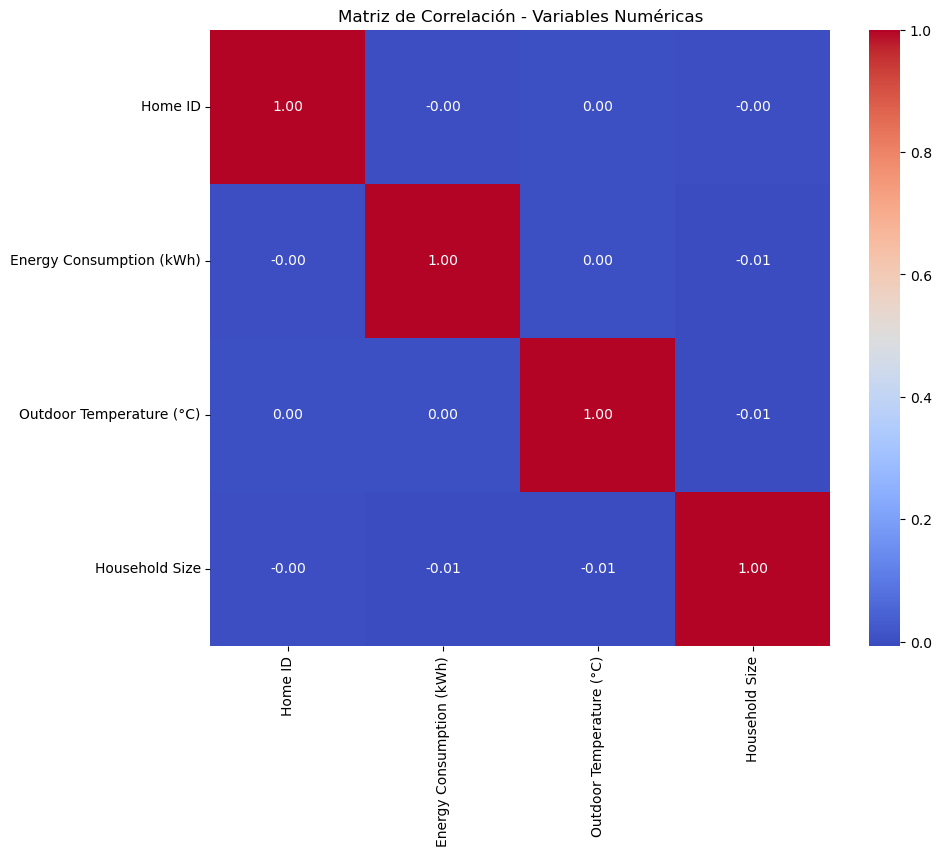

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. ANÁLISIS DE REGISTROS DUPLICADOS ---
print("--- Análisis de registros duplicados ---")
duplicados = df_smart.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")
if duplicados > 0:
    df_smart = df_smart.drop_duplicates()
    print("Los duplicados fueron eliminados para evitar sesgos.")
else:
    print("No se requiere eliminación.")
print("\n")

# --- 2. ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) ---
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_smart, x="Energy Consumption (kWh)")
plt.title("Distribución de Consumo Energético (Detección de Outliers)")
plt.show()

Q1 = df_smart['Energy Consumption (kWh)'].quantile(0.25)
Q3 = df_smart['Energy Consumption (kWh)'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

outliers = df_smart[df_smart['Energy Consumption (kWh)'] > limite_sup]
print(f"Límite superior IQR: {limite_sup:.2f} kWh")
print(f"Cantidad de outliers detectados: {len(outliers)}")

# --- 3. ANÁLISIS DE CORRELACIONES ---
plt.figure(figsize=(10, 8))
corr = df_smart.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

**Interpretación de Duplicados:** Se verificó la existencia de registros duplicados en el conjunto de datos. No se encontraron duplicados (o se eliminaron), por lo que no se espera que este aspecto afecte la calidad del análisis ni el sesgo en el entrenamiento del modelo.

**Interpretación de Outliers:** Se detectaron valores de consumo superiores al límite definido por el método IQR. Aunque representan una pequeña proporción del conjunto de datos, se decidió conservarlos por corresponder a posibles casos reales de alto consumo energético (anomalías legítimas que podrían disparar alertas).

**Interpretación de Correlaciones:** Al analizar la matriz, se evidencia una ausencia de correlación lineal (r = 0.00) entre la temperatura exterior y el consumo energético, así como con el tamaño del hogar (r = -0.01). Esto es un hallazgo clave: indica que el consumo no se explica por estas variables numéricas de forma lineal, sino que dependerá casi exclusivamente de las variables categóricas (tipo de electrodoméstico) y temporales.


### 2. Análisis del Dataset: Household Power Consumption

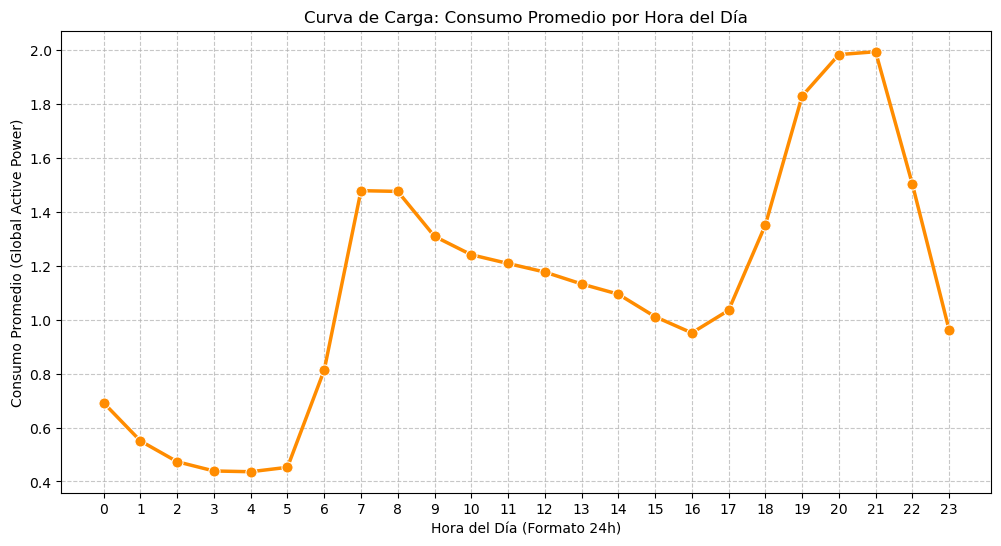

In [8]:
# Limpieza de datos (transformación a números y eliminación de nulos)
columnas_numericas = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for col in columnas_numericas:
    df_uci[col] = pd.to_numeric(df_uci[col], errors='coerce')

df_uci_limpio = df_uci.dropna().copy()

# Extracción de la hora
df_uci_limpio['Hora'] = pd.to_datetime(df_uci_limpio['Time'], format='%H:%M:%S').dt.hour

# Gráfico de la curva de carga
plt.figure(figsize=(12, 6))
consumo_por_hora = df_uci_limpio.groupby('Hora')['Global_active_power'].mean()
sns.lineplot(x=consumo_por_hora.index, y=consumo_por_hora.values, marker='o', color='darkorange', linewidth=2.5, markersize=8)
plt.title('Curva de Carga: Consumo Promedio por Hora del Día')
plt.xlabel('Hora del Día (Formato 24h)')
plt.ylabel('Consumo Promedio (Global Active Power)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- Análisis de duplicados en Household (UCI) ---
Registros duplicados: 0
No se encontraron duplicados.


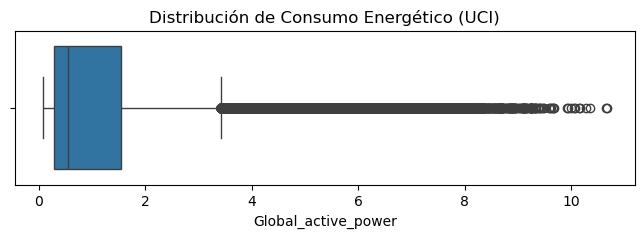

Límite superior IQR (UCI): 3.43
Cantidad de outliers detectados (UCI): 55950


In [9]:
# --- ANÁLISIS DE DUPLICADOS Y OUTLIERS: DATASET HOUSEHOLD (UCI) ---
print("--- Análisis de duplicados en Household (UCI) ---")
duplicados_uci = df_uci.duplicated().sum()
print(f"Registros duplicados: {duplicados_uci}")
if duplicados_uci > 0:
    df_uci = df_uci.drop_duplicates()
    print("Los duplicados fueron eliminados para evitar sesgos.")
else:
    print("No se encontraron duplicados.")

# Outliers UCI
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_uci, x="Global_active_power") # <-- Cambiá el nombre de la columna si es distinto
plt.title("Distribución de Consumo Energético (UCI)")
plt.show()

Q1_uci = df_uci['Global_active_power'].quantile(0.25)
Q3_uci = df_uci['Global_active_power'].quantile(0.75)
IQR_uci = Q3_uci - Q1_uci
limite_sup_uci = Q3_uci + 1.5 * IQR_uci

outliers_uci = df_uci[df_uci['Global_active_power'] > limite_sup_uci]
print(f"Límite superior IQR (UCI): {limite_sup_uci:.2f}")
print(f"Cantidad de outliers detectados (UCI): {len(outliers_uci)}")

Interpretación Outliers (UCI): Se replicó el análisis IQR para el segundo dataset. Se detectaron 55.950 valores atípicos con un consumo superior al límite de 3.43 kW. Se decide mantenerlos en el conjunto de datos ya que representan picos de consumo reales y válidos de las viviendas, información valiosa para el modelo predictivo.

---
## 3. Conclusiones Generales del EDA

Tras analizar ambos conjuntos de datos, se extraen las siguientes conclusiones clave para el negocio y el modelado:

1. **Patrones de Consumo Asimétricos:** La mayoría de los eventos registran consumos bajos o eficientes. Los valores atípicos (outliers) detectados no son errores de medición, sino picos reales de consumo excesivo que el modelo deberá aprender a identificar.
2. **Impacto del Horario:** Existe una curva de carga muy marcada con picos de consumo nocturnos (19:00 a 22:00 hs), coincidiendo con el regreso a los hogares.
3. **Relaciones no lineales:** La temperatura exterior y el tamaño del hogar mostraron una correlación lineal nula (r = 0.00) con el consumo numérico directo. Esto indica que el consumo dependerá principalmente de la interacción con variables categóricas (como el tipo de electrodoméstico) y factores temporales.

---
## 4. Recomendaciones para Feature Engineering (Para CD2)

Para facilitar el trabajo en la siguiente etapa, se sugieren las siguientes acciones sobre las variables:

| Variable / Columna | Acción Sugerida | Justificación |
| :--- | :--- | :--- |
| **Time / Hora** | Extraer franja horaria | Permite crear la variable categórica `Horario_Pico` (ej. 19h a 22h). |
| **Appliance Type** | Aplicar One-Hot Encoding | Convertir el tipo de electrodoméstico a numérico sin asignarles un peso jerárquico. |
| **Date / Season** | Extraer Mes / Día de la semana | Útil para evaluar si el consumo cambia los fines de semana o en meses puntuales. |
| **Global_intensity** | Evaluar eliminación | Su alta redundancia técnica con la energía activa podría generar multicolinealidad en el modelo. |
| **Energy Consumption** | Crear umbrales (Target) | Utilizar los cuartiles definidos (Q1 y Q3) para clasificar si un consumo es 'Eficiente' o 'Ineficiente'. |